In [2]:
import pandas as pd
import pm4py as pm
import datetime as dt

#### Первичная обработка данных

In [3]:
data = pd.read_csv('data.csv', sep =',', encoding='utf-8')
data

,ID,Time_start_case,Time_end_case,case_duration,Stage,Time,Channel,Name,Type,Hit,Place,Model,Price,Like,Time_end,duration,hour,dayofweek,month,year
0,П00001,2023-09-12 04:32:23+00:00,2023-09-14 14:32:23+00:00,2.416667,Регистрация претензии,2023-09-12 04:32:23+00:00,Офис,Денис Прохоров,Личный ущерб,ДТП со скрывшимся виновником,Краснодар,Fiat 500X Trekking AWD,128860.0,3,2023-09-12 09:32:23+00:00,300.0,4,1,9,2023
1,П00001,2023-09-12 04:32:23+00:00,2023-09-14 14:32:23+00:00,2.416667,Проверка документов,2023-09-12 09:32:23+00:00,Офис,Ксения Петрова,Личный ущерб,ДТП со скрывшимся виновником,Краснодар,Fiat 500X Trekking AWD,128860.0,3,2023-09-12 21:32:23+00:00,720.0,9,1,9,2023
2,П00001,2023-09-12 04:32:23+00:00,2023-09-14 14:32:23+00:00,2.416667,Поиск потерянной документации,2023-09-12 21:32:23+00:00,Офис,Алексей Лопухин,Личный ущерб,ДТП со скрывшимся виновником,Краснодар,Fiat 500X Trekking AWD,128860.0,3,2023-09-12 23:32:23+00:00,120.0,21,1,9,2023
3,П00001,2023-09-12 04:32:23+00:00,2023-09-14 14:32:23+00:00,2.416667,Проверка документов,2023-09-12 23:32:23+00:00,Офис,Алексей Лопухин,Личный ущерб,ДТП со скрывшимся виновником,Краснодар,Fiat 500X Trekking AWD,128860.0,3,2023-09-13 11:32:23+00:00,720.0,23,1,9,2023
4,П00001,2023-09-12 04:32:23+00:00,2023-09-14 14:32:23+00:00,2.416667,Урегулирование претензии,2023-09-13 11:32:23+00:00,Офис,Сидоров Илья,Личный ущерб,ДТП со скрывшимся виновником,Краснодар,Fiat 500X Trekking AWD,128860.0,3,2023-09-14 07:32:23+00:00,1200.0,11,2,9,2023
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
441545,П09999,2024-08-08 21:17:58+00:00,2024-08-09 15:20:58+00:00,0.752083,Получение права на предъявление претензий от с...,2024-08-09 10:20:58+00:00,Офис,Денис Прохоров,Ответственность перед третьими лицами,Боковое столкновение,Челябинск,Lexus LX 600 AWD,526065.0,4,2024-08-09 11:20:58+00:00,60.0,10,4,8,2024
441546,П09999,2024-08-08 21:17:58+00:00,2024-08-09 15:20:58+00:00,0.752083,Ремонт автомобиля,2024-08-09 11:20:58+00:00,Офис,Геннадий Кривцов,Ответственность перед третьими лицами,Боковое столкновение,Челябинск,Lexus LX 600 AWD,526065.0,4,2024-08-09 12:20:58+00:00,60.0,11,4,8,2024
441547,П09999,2024-08-08 21:17:58+00:00,2024-08-09 15:20:58+00:00,0.752083,Подготовка итоговой документации,2024-08-09 12:20:58+00:00,Офис,Сергей Петров,Ответственность перед третьими лицами,Боковое столкновение,Челябинск,Lexus LX 600 AWD,526065.0,4,2024-08-09 13:20:58+00:00,60.0,12,4,8,2024
441548,П09999,2024-08-08 21:17:58+00:00,2024-08-09 15:20:58+00:00,0.752083,Закрытие страхового случая,2024-08-09 13:20:58+00:00,Офис,Елизавета Нестерова,Ответственность перед третьими лицами,Боковое столкновение,Челябинск,Lexus LX 600 AWD,526065.0,4,2024-08-09 15:20:58+00:00,120.0,13,4,8,2024


#### Переименование столбцов для обработки в pm4py

In [4]:
df = pm.format_dataframe(data,
    case_id='ID',
    activity_key='Stage',
    start_timestamp_key='Time',
    timestamp_key='Time_end')
df

,ID,Time_start_case,Time_end_case,case_duration,Stage,Time,Channel,Name,Type,Hit,...,hour,dayofweek,month,year,case:concept:name,concept:name,time:timestamp,@@index,@@case_index,start_timestamp
0,П00001,2023-09-12 04:32:23+00:00,2023-09-14 14:32:23+00:00,2.416667,Регистрация претензии,2023-09-12 04:32:23+00:00,Офис,Денис Прохоров,Личный ущерб,ДТП со скрывшимся виновником,...,4,1,9,2023,П00001,Регистрация претензии,2023-09-12 09:32:23+00:00,0,0,2023-09-12 04:32:23+00:00
1,П00001,2023-09-12 04:32:23+00:00,2023-09-14 14:32:23+00:00,2.416667,Проверка документов,2023-09-12 09:32:23+00:00,Офис,Ксения Петрова,Личный ущерб,ДТП со скрывшимся виновником,...,9,1,9,2023,П00001,Проверка документов,2023-09-12 21:32:23+00:00,1,0,2023-09-12 09:32:23+00:00
2,П00001,2023-09-12 04:32:23+00:00,2023-09-14 14:32:23+00:00,2.416667,Поиск потерянной документации,2023-09-12 21:32:23+00:00,Офис,Алексей Лопухин,Личный ущерб,ДТП со скрывшимся виновником,...,21,1,9,2023,П00001,Поиск потерянной документации,2023-09-12 23:32:23+00:00,2,0,2023-09-12 21:32:23+00:00
3,П00001,2023-09-12 04:32:23+00:00,2023-09-14 14:32:23+00:00,2.416667,Проверка документов,2023-09-12 23:32:23+00:00,Офис,Алексей Лопухин,Личный ущерб,ДТП со скрывшимся виновником,...,23,1,9,2023,П00001,Проверка документов,2023-09-13 11:32:23+00:00,3,0,2023-09-12 23:32:23+00:00
4,П00001,2023-09-12 04:32:23+00:00,2023-09-14 14:32:23+00:00,2.416667,Урегулирование претензии,2023-09-13 11:32:23+00:00,Офис,Сидоров Илья,Личный ущерб,ДТП со скрывшимся виновником,...,11,2,9,2023,П00001,Урегулирование претензии,2023-09-14 07:32:23+00:00,4,0,2023-09-13 11:32:23+00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
441545,П09999,2024-08-08 21:17:58+00:00,2024-08-09 15:20:58+00:00,0.752083,Получение права на предъявление претензий от с...,2024-08-09 10:20:58+00:00,Офис,Денис Прохоров,Ответственность перед третьими лицами,Боковое столкновение,...,10,4,8,2024,П09999,Получение права на предъявление претензий от с...,2024-08-09 11:20:58+00:00,441545,49872,2024-08-09 10:20:58+00:00
441546,П09999,2024-08-08 21:17:58+00:00,2024-08-09 15:20:58+00:00,0.752083,Ремонт автомобиля,2024-08-09 11:20:58+00:00,Офис,Геннадий Кривцов,Ответственность перед третьими лицами,Боковое столкновение,...,11,4,8,2024,П09999,Ремонт автомобиля,2024-08-09 12:20:58+00:00,441546,49872,2024-08-09 11:20:58+00:00
441547,П09999,2024-08-08 21:17:58+00:00,2024-08-09 15:20:58+00:00,0.752083,Подготовка итоговой документации,2024-08-09 12:20:58+00:00,Офис,Сергей Петров,Ответственность перед третьими лицами,Боковое столкновение,...,12,4,8,2024,П09999,Подготовка итоговой документации,2024-08-09 13:20:58+00:00,441547,49872,2024-08-09 12:20:58+00:00
441548,П09999,2024-08-08 21:17:58+00:00,2024-08-09 15:20:58+00:00,0.752083,Закрытие страхового случая,2024-08-09 13:20:58+00:00,Офис,Елизавета Нестерова,Ответственность перед третьими лицами,Боковое столкновение,...,13,4,8,2024,П09999,Закрытие страхового случая,2024-08-09 15:20:58+00:00,441548,49872,2024-08-09 13:20:58+00:00


#### Преобразование в log формат

In [5]:
log = pm.convert_to_event_log(df)
log

[{'attributes': {'concept:name': 'П00001'}, 'events': [{'ID': 'П00001', 'Time_start_case': Timestamp('2023-09-12 04:32:23+0000', tz='UTC'), 'Time_end_case': Timestamp('2023-09-14 14:32:23+0000', tz='UTC'), 'case_duration': 2.4166666666666665, 'Stage': 'Регистрация претензии', 'Time': Timestamp('2023-09-12 04:32:23+0000', tz='UTC'), 'Channel': 'Офис', 'Name': 'Денис Прохоров', 'Type': 'Личный ущерб', 'Hit': 'ДТП со скрывшимся виновником', 'Place': 'Краснодар', 'Model': 'Fiat 500X Trekking AWD', 'Price': 128860.0, 'Like': 3, 'Time_end': Timestamp('2023-09-12 09:32:23+0000', tz='UTC'), 'duration': 300.0, 'hour': 4, 'dayofweek': 1, 'month': 9, 'year': 2023, 'concept:name': 'Регистрация претензии', 'time:timestamp': Timestamp('2023-09-12 09:32:23+0000', tz='UTC'), '@@index': 0, '@@case_index': 0, 'start_timestamp': Timestamp('2023-09-12 04:32:23+0000', tz='UTC')}, '..', {'ID': 'П00001', 'Time_start_case': Timestamp('2023-09-12 04:32:23+0000', tz='UTC'), 'Time_end_case': Timestamp('2023-09-1

#### Создание визуализации в формате сети Petri

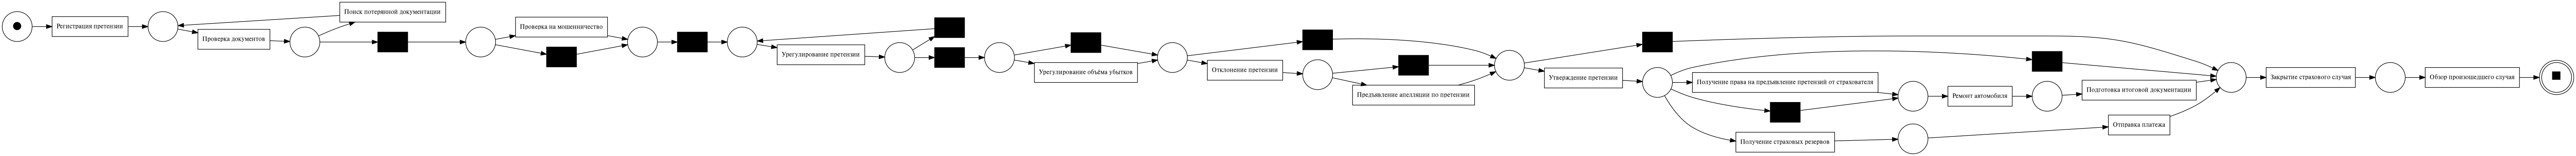

In [6]:
net, initial_marking, final_marking = pm.discover_petri_net_inductive(log)
pm.view_petri_net(net, initial_marking, final_marking)

#### Создание визуализации Бизнес-процесса в формате bpmn-модели

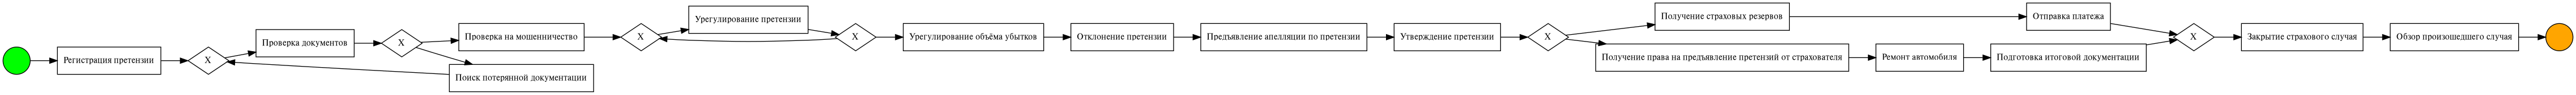

In [7]:
bpmn_model = pm.discover_bpmn_inductive(log, 0.95)
pm.view_bpmn(bpmn_model)
pm.write_bpmn(bpmn_model, 'process_model.bpmn')

#### Создание визуализации Бизнесс-процесса в формате Графа прямого следования (DFG)

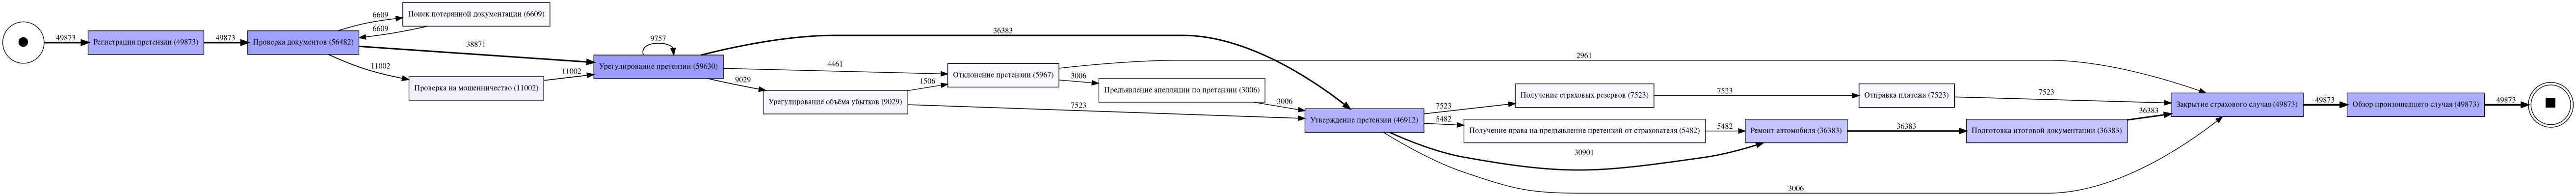

In [8]:
dfg, start_activities, end_activities = pm.discover_dfg(log)
pm.view_dfg(dfg, start_activities, end_activities)

#### Создание вариантов потоков реализации Бизнес-процесса

In [9]:
variants = pm.get_variants(log)
variants_len = variants
print(f"Найдено вариантов: {len(variants)}")
print("Варианты и количество кейсов:")

for variant, cases in variants.items():
    print(f"{variant}: {len(cases)} кейсов")

Найдено вариантов: 11
Варианты и количество кейсов:
('Регистрация претензии', 'Проверка документов', 'Поиск потерянной документации', 'Проверка документов', 'Урегулирование претензии', 'Утверждение претензии', 'Ремонт автомобиля', 'Подготовка итоговой документации', 'Закрытие страхового случая', 'Обзор произошедшего случая'): 3487 кейсов
('Регистрация претензии', 'Проверка документов', 'Проверка на мошенничество', 'Урегулирование претензии', 'Урегулирование претензии', 'Утверждение претензии', 'Ремонт автомобиля', 'Подготовка итоговой документации', 'Закрытие страхового случая', 'Обзор произошедшего случая'): 5044 кейсов
('Регистрация претензии', 'Проверка документов', 'Урегулирование претензии', 'Утверждение претензии', 'Ремонт автомобиля', 'Подготовка итоговой документации', 'Закрытие страхового случая', 'Обзор произошедшего случая'): 14851 кейсов
('Регистрация претензии', 'Проверка документов', 'Проверка на мошенничество', 'Урегулирование претензии', 'Утверждение претензии', 'Ремонт

#### Приведение к формату Датафрейма и сохранение Вариантов в формате csv

In [10]:
variants_df = pd.DataFrame([
    {'variant': variant, 'count': count} 
    for variant, count in variants.items()
])
variants_df.to_csv('process_variants.csv', index=False, encoding='utf-8')

#### Назначение операциям (этапам) символов

In [11]:
un_stage = df['Stage'].unique()
nun_stage = df['Stage'].nunique()
alpha = 'ABCDEFGHIJKLMNOPRSTUFQVWXYZ'
n = 0
alpha_stage = []
while n < nun_stage:
    buff = {
            'stage': un_stage[n],
            'sym': alpha[n]
            }
    alpha_stage.append(buff)
    n += 1
alpha_var = pd.DataFrame(alpha_stage)
alpha_var

,stage,sym
0,Регистрация претензии,A
1,Проверка документов,B
2,Поиск потерянной документации,C
3,Урегулирование претензии,D
4,Утверждение претензии,E
5,Ремонт автомобиля,F
6,Подготовка итоговой документации,G
7,Закрытие страхового случая,H
8,Обзор произошедшего случая,I
9,Проверка на мошенничество,J


#### Присовение буквенных обозначений вариантам, а также определение зацикленностей в них

In [12]:
var_list = []
alpha_buf = {item['stage']: item['sym'] for item in alpha_stage}
for index, row in variants_df.iterrows():
    n = 0
    x = len(row['variant'])
    word_list = [''] * x
    cycle = 'no'
    while n < x:
        word_list[n] = alpha_buf[row['variant'][n]]
        m = 0
        if cycle == 'no' or cycle == 'Возврат' or cycle == 'В себя: разово':
            while m < n:
                if word_list[m] == word_list[n]:
                    c = n - m
                    if cycle == 'Возврат' and c == 2:
                        cycle = 'Пинг-Понг'
                        m = n
                    elif c == 1:
                        cycle = 'В себя: разово'
                        m += 1
                    elif c > 2 and m == 0:
                        cycle = 'В начало'
                        m = n
                    elif c > 2:
                        cycle = 'В себя: многократно'
                        m = n
                    elif c == 2:
                        cycle = 'Возврат'
                        m += 1 
                else:
                    m += 1
        n += 1
    word_str = ''.join(word_list)
    x = len(row['count'])
    n = 0 
    while n < x:
        l = row['count'][n]
        buf = {
           'case': l.attributes['concept:name'],
           'variant': row['variant'],
           'word': word_str,
           'cycle': cycle
        }
        var_list.append(buf)
        n += 1
name_var = pd.DataFrame(var_list)
name_var

,case,variant,word,cycle
0,П00001,"(Регистрация претензии, Проверка документов, П...",ABCBDEFGHI,Возврат
1,П00006,"(Регистрация претензии, Проверка документов, П...",ABCBDEFGHI,Возврат
2,П00014,"(Регистрация претензии, Проверка документов, П...",ABCBDEFGHI,Возврат
3,П00043,"(Регистрация претензии, Проверка документов, П...",ABCBDEFGHI,Возврат
4,П00061,"(Регистрация претензии, Проверка документов, П...",ABCBDEFGHI,Возврат
...,...,...,...,...
49868,П09866,"(Регистрация претензии, Проверка документов, П...",ABJDDDDEFGHI,В себя: многократно
49869,П09869,"(Регистрация претензии, Проверка документов, П...",ABJDDDDEFGHI,В себя: многократно
49870,П09947,"(Регистрация претензии, Проверка документов, П...",ABJDDDDEFGHI,В себя: многократно
49871,П09990,"(Регистрация претензии, Проверка документов, П...",ABJDDDDEFGHI,В себя: многократно


In [13]:
name_var.to_csv('case_cycle.csv', index=False, encoding='utf-8')

#### Формирование финального датасета с описанием конкретных экземпляров и вариантов, которым они соответствуют

In [14]:
name_var = name_var.rename(columns={'case':'ID'})
final_data = pd.merge(data, name_var, on='ID')
final_data

,ID,Time_start_case,Time_end_case,case_duration,Stage,Time,Channel,Name,Type,Hit,...,hour,dayofweek,month,year,case:concept:name,concept:name,time:timestamp,variant,word,cycle
0,П00001,2023-09-12 04:32:23+00:00,2023-09-14 14:32:23+00:00,2.416667,Регистрация претензии,2023-09-12 04:32:23+00:00,Офис,Денис Прохоров,Личный ущерб,ДТП со скрывшимся виновником,...,4,1,9,2023,П00001,Регистрация претензии,2023-09-12 09:32:23+00:00,"(Регистрация претензии, Проверка документов, П...",ABCBDEFGHI,Возврат
1,П00001,2023-09-12 04:32:23+00:00,2023-09-14 14:32:23+00:00,2.416667,Проверка документов,2023-09-12 09:32:23+00:00,Офис,Ксения Петрова,Личный ущерб,ДТП со скрывшимся виновником,...,9,1,9,2023,П00001,Проверка документов,2023-09-12 21:32:23+00:00,"(Регистрация претензии, Проверка документов, П...",ABCBDEFGHI,Возврат
2,П00001,2023-09-12 04:32:23+00:00,2023-09-14 14:32:23+00:00,2.416667,Поиск потерянной документации,2023-09-12 21:32:23+00:00,Офис,Алексей Лопухин,Личный ущерб,ДТП со скрывшимся виновником,...,21,1,9,2023,П00001,Поиск потерянной документации,2023-09-12 23:32:23+00:00,"(Регистрация претензии, Проверка документов, П...",ABCBDEFGHI,Возврат
3,П00001,2023-09-12 04:32:23+00:00,2023-09-14 14:32:23+00:00,2.416667,Проверка документов,2023-09-12 23:32:23+00:00,Офис,Алексей Лопухин,Личный ущерб,ДТП со скрывшимся виновником,...,23,1,9,2023,П00001,Проверка документов,2023-09-13 11:32:23+00:00,"(Регистрация претензии, Проверка документов, П...",ABCBDEFGHI,Возврат
4,П00001,2023-09-12 04:32:23+00:00,2023-09-14 14:32:23+00:00,2.416667,Урегулирование претензии,2023-09-13 11:32:23+00:00,Офис,Сидоров Илья,Личный ущерб,ДТП со скрывшимся виновником,...,11,2,9,2023,П00001,Урегулирование претензии,2023-09-14 07:32:23+00:00,"(Регистрация претензии, Проверка документов, П...",ABCBDEFGHI,Возврат
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
441545,П09999,2024-08-08 21:17:58+00:00,2024-08-09 15:20:58+00:00,0.752083,Получение права на предъявление претензий от с...,2024-08-09 10:20:58+00:00,Офис,Денис Прохоров,Ответственность перед третьими лицами,Боковое столкновение,...,10,4,8,2024,П09999,Получение права на предъявление претензий от с...,2024-08-09 11:20:58+00:00,"(Регистрация претензии, Проверка документов, У...",ABDENFGHI,no
441546,П09999,2024-08-08 21:17:58+00:00,2024-08-09 15:20:58+00:00,0.752083,Ремонт автомобиля,2024-08-09 11:20:58+00:00,Офис,Геннадий Кривцов,Ответственность перед третьими лицами,Боковое столкновение,...,11,4,8,2024,П09999,Ремонт автомобиля,2024-08-09 12:20:58+00:00,"(Регистрация претензии, Проверка документов, У...",ABDENFGHI,no
441547,П09999,2024-08-08 21:17:58+00:00,2024-08-09 15:20:58+00:00,0.752083,Подготовка итоговой документации,2024-08-09 12:20:58+00:00,Офис,Сергей Петров,Ответственность перед третьими лицами,Боковое столкновение,...,12,4,8,2024,П09999,Подготовка итоговой документации,2024-08-09 13:20:58+00:00,"(Регистрация претензии, Проверка документов, У...",ABDENFGHI,no
441548,П09999,2024-08-08 21:17:58+00:00,2024-08-09 15:20:58+00:00,0.752083,Закрытие страхового случая,2024-08-09 13:20:58+00:00,Офис,Елизавета Нестерова,Ответственность перед третьими лицами,Боковое столкновение,...,13,4,8,2024,П09999,Закрытие страхового случая,2024-08-09 15:20:58+00:00,"(Регистрация претензии, Проверка документов, У...",ABDENFGHI,no


In [15]:
final_data.to_csv('final_data.csv', index=False, encoding='utf-8')

In [16]:
data_to_bpmn = final_data[final_data['word'] == 'ABDEFGHI']
data_to_bpmn

,ID,Time_start_case,Time_end_case,case_duration,Stage,Time,Channel,Name,Type,Hit,...,hour,dayofweek,month,year,case:concept:name,concept:name,time:timestamp,variant,word,cycle
20,П00003,2024-05-13 23:30:32+00:00,2024-05-14 20:33:32+00:00,0.877083,Регистрация претензии,2024-05-13 23:30:32+00:00,Офис,Владимир Воробьёв,Личный ущерб,Переднее столкновение,...,23,0,5,2024,П00003,Регистрация претензии,2024-05-14 05:30:32+00:00,"(Регистрация претензии, Проверка документов, У...",ABDEFGHI,no
21,П00003,2024-05-13 23:30:32+00:00,2024-05-14 20:33:32+00:00,0.877083,Проверка документов,2024-05-14 05:30:32+00:00,Офис,Анна Егорова,Личный ущерб,Переднее столкновение,...,5,1,5,2024,П00003,Проверка документов,2024-05-14 13:30:32+00:00,"(Регистрация претензии, Проверка документов, У...",ABDEFGHI,no
22,П00003,2024-05-13 23:30:32+00:00,2024-05-14 20:33:32+00:00,0.877083,Урегулирование претензии,2024-05-14 13:30:32+00:00,Офис,Владимир Воробьёв,Личный ущерб,Переднее столкновение,...,13,1,5,2024,П00003,Урегулирование претензии,2024-05-14 13:33:32+00:00,"(Регистрация претензии, Проверка документов, У...",ABDEFGHI,no
23,П00003,2024-05-13 23:30:32+00:00,2024-05-14 20:33:32+00:00,0.877083,Утверждение претензии,2024-05-14 13:33:32+00:00,Офис,Анна Егорова,Личный ущерб,Переднее столкновение,...,13,1,5,2024,П00003,Утверждение претензии,2024-05-14 14:33:32+00:00,"(Регистрация претензии, Проверка документов, У...",ABDEFGHI,no
24,П00003,2024-05-13 23:30:32+00:00,2024-05-14 20:33:32+00:00,0.877083,Ремонт автомобиля,2024-05-14 14:33:32+00:00,Офис,Анна Егорова,Личный ущерб,Переднее столкновение,...,14,1,5,2024,П00003,Ремонт автомобиля,2024-05-14 16:33:32+00:00,"(Регистрация претензии, Проверка документов, У...",ABDEFGHI,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
441506,П09995,2025-01-19 14:39:28+00:00,2025-01-21 08:39:28+00:00,1.750000,Утверждение претензии,2025-01-21 03:39:28+00:00,Сайт,Алексей Лопухин,Личный ущерб,Столкновение нескольких автомобилей,...,3,1,1,2025,П09995,Утверждение претензии,2025-01-21 05:39:28+00:00,"(Регистрация претензии, Проверка документов, У...",ABDEFGHI,no
441507,П09995,2025-01-19 14:39:28+00:00,2025-01-21 08:39:28+00:00,1.750000,Ремонт автомобиля,2025-01-21 05:39:28+00:00,Сайт,Сергей Петров,Личный ущерб,Столкновение нескольких автомобилей,...,5,1,1,2025,П09995,Ремонт автомобиля,2025-01-21 06:39:28+00:00,"(Регистрация претензии, Проверка документов, У...",ABDEFGHI,no
441508,П09995,2025-01-19 14:39:28+00:00,2025-01-21 08:39:28+00:00,1.750000,Подготовка итоговой документации,2025-01-21 06:39:28+00:00,Сайт,Алексей Лопухин,Личный ущерб,Столкновение нескольких автомобилей,...,6,1,1,2025,П09995,Подготовка итоговой документации,2025-01-21 07:39:28+00:00,"(Регистрация претензии, Проверка документов, У...",ABDEFGHI,no
441509,П09995,2025-01-19 14:39:28+00:00,2025-01-21 08:39:28+00:00,1.750000,Закрытие страхового случая,2025-01-21 07:39:28+00:00,Сайт,Леонид Куликов,Личный ущерб,Столкновение нескольких автомобилей,...,7,1,1,2025,П09995,Закрытие страхового случая,2025-01-21 08:39:28+00:00,"(Регистрация претензии, Проверка документов, У...",ABDEFGHI,no


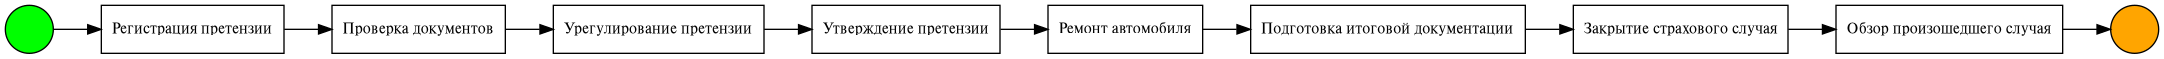

In [17]:
bpmn_log = pm.convert_to_event_log(data_to_bpmn)
bpmn_to_model = pm.discover_bpmn_inductive(bpmn_log, 0.7)
pm.view_bpmn(bpmn_to_model)
pm.write_bpmn(bpmn_to_model, 'process_model+.bpmn')